In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [90]:
df = pd.read_csv('heartDisease.csv')

In [91]:
df.shape

(303, 14)

In [92]:
df.diagnosis.value_counts()

diagnosis
Abnormal    165
Normal      138
Name: count, dtype: int64

In [93]:
#cleaning

In [94]:
df.isnull().sum()

age                    0
sex                    0
chest pain             0
trestbps               0
cholestoral            0
fasting blood sugar    0
restecg                0
heartbeat              0
exang                  0
oldpeak                0
slope                  0
ca                     0
thalium                0
diagnosis              0
dtype: int64

In [95]:
df.duplicated().sum()

np.int64(1)

In [96]:
df = df.drop_duplicates()

In [97]:
df.duplicated().sum()

np.int64(0)

In [98]:
#eda

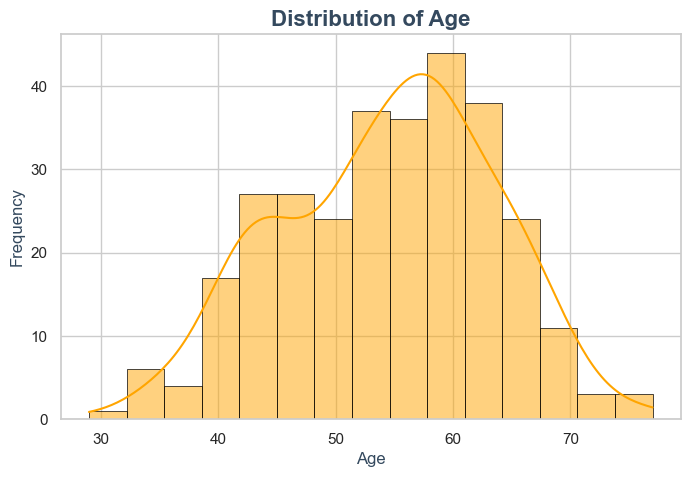

In [99]:
sns.set(style = 'whitegrid')
plt.figure(figsize = (8, 5))
sns.histplot(data=df, x = 'age', bins=15, kde = True, color= 'orange', edgecolor = 'black', linewidth = 0.5)
#kde = kernel density estimate
plt.title('Distribution of Age', fontsize=16, fontweight='bold', color='#34495E')
plt.xlabel('Age', fontsize=12, color='#34495E')
plt.ylabel('Frequency', fontsize=12, color='#34495E')
plt.show();

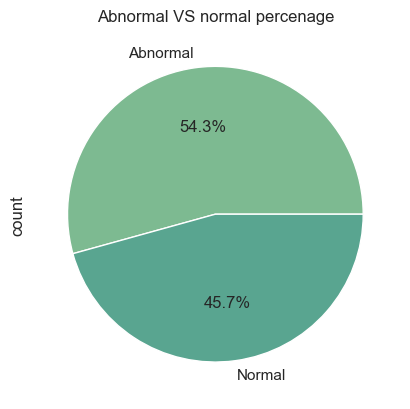

In [100]:
sns.set_palette('crest')
df['diagnosis'].value_counts().plot(kind = 'pie', autopct = '%1.1f%%')
plt.title('Abnormal VS normal percenage')
plt.show()

In [101]:
#label encoding

In [102]:
from sklearn.preprocessing import LabelEncoder

In [103]:
sx_encoder = LabelEncoder()

In [104]:
cp_encoder = LabelEncoder()

In [105]:
s_encoder = LabelEncoder()

In [106]:
df['sex'] = sx_encoder.fit_transform(df['sex'])

In [107]:
df['chest pain'] = cp_encoder.fit_transform(df['chest pain'])

In [108]:
df['slope'] = s_encoder.fit_transform(df['slope'])

In [109]:
df['diagnosis'] = df['diagnosis'].map({'Abnormal': 1, 'Normal': 0})

In [110]:
df.head()

,age,sex,chest pain,trestbps,cholestoral,fasting blood sugar,restecg,heartbeat,exang,oldpeak,slope,ca,thalium,diagnosis
0,63,1,0,145,233,1,0,150,0,2.3,2,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,2,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,0,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,0,0,2,1
4,57,0,3,120,354,0,1,163,1,0.6,0,0,2,1


In [111]:
X = df.drop(columns = 'diagnosis')

In [112]:
y = df['diagnosis']

In [113]:
print('X:', X.shape)

X: (302, 13)


In [114]:
print('y:', y.shape)

y: (302,)


In [115]:
#####

In [116]:
scaler = StandardScaler()

In [117]:
scaler.fit(X)

StandardScaler()

In [118]:
X = scaler.fit_transform(X)

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [120]:
#modeling and evaluating (SVM, KNN, Decision Tree)

In [121]:
from sklearn.neighbors import KNeighborsClassifier

In [122]:
models = {
    'Decision Tree': DecisionTreeClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(kernel = 'linear')

}

In [123]:
result = []
for x, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict = True)

    result.append({
        'Model': x,
        'Accuracy': accuracy,
        'Precision': report["weighted avg"]["precision"],
        'Recall': report["weighted avg"]["recall"],
        'F1-Score': report["weighted avg"]["f1-score"]
    })

evaluation_df = pd.DataFrame(result)
evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.813187,0.815496,0.813187,0.813458
1,K-Nearest Neighbors,0.846154,0.849870,0.846154,0.846377
2,Support Vector Machine,0.824176,0.824176,0.824176,0.824176


In [124]:
#testing

In [125]:
# Collect user inputs
age = int(input("Enter age: "))
sex = input("Enter sex (Male/Female): ").capitalize()
chest_pain = input("Enter chest pain type (Asymptomatic / Non-anginal pain / Atypical angina / Typical angina): ").capitalize()
trestbps = int(input("Enter resting blood pressure (trestbps): "))
cholestoral = int(input("Enter cholestoral level: "))
fbs = int(input("Enter fasting blood sugar (1 = True, 0 = False): "))
restecg = int(input("Enter resting ECG (0, 1, or 2): "))
heartbeat = int(input("Enter maximum heart rate achieved: "))
exang = int(input("Exercise induced angina (1 = Yes, 0 = No): "))
oldpeak = float(input("Enter ST depression induced by exercise (oldpeak): "))
slope = input("Enter slope type (Upsloping / Flatsloping / Downsloping): ").capitalize()
ca = int(input("Enter number of major vessels (0–4): "))
thalium = int(input("Enter thalium value (0–3): "))

# Create DataFrame
new_data = pd.DataFrame({
    'age': [age],
    'sex': [sex],
    'chest pain': [chest_pain],
    'trestbps': [trestbps],
    'cholestoral': [cholestoral],
    'fasting blood sugar': [fbs],
    'restecg': [restecg],
    'heartbeat': [heartbeat],
    'exang': [exang],
    'oldpeak': [oldpeak],
    'slope': [slope],
    'ca': [ca],
    'thalium': [thalium],
})

print("\n✅ User Input DataFrame:")
display(new_data)


Enter age:  50
Enter sex (Male/Female):  Male
Enter chest pain type (Asymptomatic / Non-anginal pain / Atypical angina / Typical angina):  Typical angina
Enter resting blood pressure (trestbps):  144
Enter cholestoral level:  200
Enter fasting blood sugar (1 = True, 0 = False):  0
Enter resting ECG (0, 1, or 2):  0
Enter maximum heart rate achieved:  152
Exercise induced angina (1 = Yes, 0 = No):  1
Enter ST depression induced by exercise (oldpeak):  0.8
Enter slope type (Upsloping / Flatsloping / Downsloping):  Flatsloping
Enter number of major vessels (0–4):  1
Enter thalium value (0–3):  1



✅ User Input DataFrame:


,age,sex,chest pain,trestbps,cholestoral,fasting blood sugar,restecg,heartbeat,exang,oldpeak,slope,ca,thalium
0,50,Male,Typical angina,144,200,0,0,152,1,0.8,Flatsloping,1,1


In [126]:
new_data['sex'] = sx_encoder.transform(new_data['sex'])
new_data['chest pain'] = cp_encoder.transform(new_data['chest pain'])
new_data['slope'] = s_encoder.transform(new_data['slope'])
new_data

,age,sex,chest pain,trestbps,cholestoral,fasting blood sugar,restecg,heartbeat,exang,oldpeak,slope,ca,thalium
0,50,1,3,144,200,0,0,152,1,0.8,1,1,1


In [128]:
new_data_scaled = scaler.transform(new_data)

for x, model in models.items():
    prediction = model.predict(new_data_scaled)
    print(f"Prediction for {model_name}: {'Abnormal' if prediction[0] == 1 else 'Normal'}")

Prediction for Support Vector Machine: Normal
Prediction for Support Vector Machine: Normal
Prediction for Support Vector Machine: Normal
